<div style="background-color:#1F3864; color:white; padding:20px; border-radius:8px;">
<h1 style="margin:0; color:white;"><b>Evaluación de Modelos de Agrupamiento</b></h1>
<h3 style="margin:5px 0 0 0; color:#BDD7EE;"><b>BIY7121 — Minería de Datos | DuocUC, Escuela de Informática y Telecomunicaciones</b></h3>
<h3 style="margin:5px 0 0 0; color:#BDD7EE;"><b>Segmentación de clientes bancarios</b></h3>
</div>

---

| Integrante | Rol |
|------------|-----|
| Benjamin Herrera | Estudiante |

---

**Nivel Bloom:** 3–4 (Aplicación y Análisis)  
**Metodología:** CRISP-DM (fases *Modeling* y *Evaluation*)

Este cuaderno enseña a **evaluar la calidad de un agrupamiento (clustering)**. A diferencia de la clasificación, en el agrupamiento **no tenemos una respuesta correcta** para comparar: el algoritmo inventa los grupos por sí solo. Por eso necesitamos métricas especiales que nos digan si los grupos encontrados son buenos.

Recorreremos las tres preguntas clave de la evaluación, siguiendo a Han, Pei & Tong (2022):

1. **¿Tiene sentido agrupar estos datos?** → *Tendencia a la agrupación* (estadística de Hopkins).
2. **¿En cuántos grupos los dividimos?** → *Número de clusters* (método de Elbow).
3. **¿Qué tan buenos son los grupos?** → *Validación intrínseca y extrínseca*.

> **Caso aplicado:** segmentación de clientes de un banco (inspirado en datos de crédito), un problema típico en BancoChile o Falabella para diseñar ofertas a la medida de cada perfil.

---


---

## 📖 Glosario para Lectores No Técnicos

| Término | Significado Simple |
|---------|-------------------|
| **Clustering / Agrupamiento** | Agrupar datos automáticamente sin saber las respuestas |
| **K-Means** | Algoritmo que divide los datos en K grupos según su cercanía |
| **WCSS / Inercia** | Suma de distancias de cada punto al centro de su grupo |
| **Silhouette** | Mide qué tan bien encaja cada punto en su grupo (-1 a 1) |
| **Hopkins** | Prueba estadística que detecta si los datos tienen estructura |
| **Estandarizar** | Escalar variables para que todas tengan el mismo peso |
| **ARI** | Índice de Rand Ajustado: compara grupos contra la verdad (1=perfecto) |

---


## **Índice**

1. [Preparación del Entorno](#1-preparacion-del-entorno)
2. [Los Datos](#2-los-datos)
3. [Tarea 1: Tendencia a la Agrupación](#3-tarea-1--tiene-sentido-agrupar-tendencia-a-la-agrupacion)
4. [Tarea 2: Número de Clusters](#4-tarea-2--en-cuantos-grupos-metodo-de-elbow)
5. [Validación Intrínseca](#5-validacion-intrinseca-sin-etiquetas-verdaderas)
6. [Validación Extrínseca](#6-validacion-extrinseca-con-etiquetas-verdaderas)
7. [Interpretación de Negocio](#7-interpretacion-de-negocio-perfilando-los-clusters)
8. [Resumen y Puntos Clave](#8-resumen-y-puntos-clave)

---


## **1. Preparación del Entorno**

<span style="color:#2E75B6;">**1.1 Imports y configuración:**</span> Antes de cualquier análisis cargamos las librerías. Usaremos `scikit-learn` para los algoritmos y las métricas, `pandas` y `numpy` para manejar los datos, y `matplotlib` para los gráficos. Fijamos la semilla `42` para que los resultados sean **reproducibles** (cualquier compañero obtendrá exactamente los mismos números).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             calinski_harabasz_score,
                             adjusted_rand_score, fowlkes_mallows_score)
import warnings
warnings.filterwarnings("ignore")

# --- Configuración ---
SEMILLA = 42
COLOR_TITULO    = "#1F3864"
COLOR_DESTACADO = "#2E75B6"

np.random.seed(SEMILLA)
pd.options.display.float_format = "{:,.4f}".format

print("Librerías cargadas correctamente. Semilla fijada en", SEMILLA)


Librerías cargadas correctamente. Semilla fijada en 42


## **2. Los Datos**

<span style="color:#2E75B6;">**2.1 Generación de datos sintéticos:**</span> Para enseñar **todas** las métricas necesitamos un conjunto de datos donde conozcamos de antemano los grupos verdaderos (las "etiquetas reales"). Esto nos permitirá comparar después lo que el algoritmo descubre contra la verdad.

Generamos **600 clientes simulados** con `make_blobs`, que crea grupos bien definidos. Cada cliente tiene tres atributos numéricos que interpretaremos como **Edad**, **Monto de crédito** y **Duración** del crédito. Por diseño, los datos esconden **4 segmentos reales** de clientes.

> Usamos datos sintéticos (en lugar de descargarlos de internet) para que el cuaderno funcione en cualquier computador sin conexión, tal como exige el entorno de laboratorio.


In [2]:
X, y_real = make_blobs(n_samples=600, centers=4, n_features=3,
                       cluster_std=1.1, random_state=SEMILLA)

datos = pd.DataFrame(X, columns=["Edad", "Monto_credito", "Duracion"])
print("Forma del dataset:", datos.shape)
datos.head()


Forma del dataset: (600, 3)


,Edad,Monto_credito,Duracion
0,6.5345,-10.2546,10.2145
1,4.9523,-8.4927,8.5657
2,3.2374,-7.6531,-6.9186
3,3.1852,-10.0695,10.1928
4,-8.1683,6.1220,1.6743


Tenemos un `DataFrame` de **600 filas (clientes) y 3 columnas (atributos)**. La variable `y_real` guarda el grupo verdadero de cada cliente, pero la dejaremos "escondida": el algoritmo no la verá. Solo la usaremos al final para evaluar.


<span style="color:#2E75B6;">**2.2 Mirada visual a los datos crudos:**</span> Antes de agrupar conviene "ver" los datos. Un gráfico 3D nos muestra si a simple vista se distinguen nubes de puntos separadas.


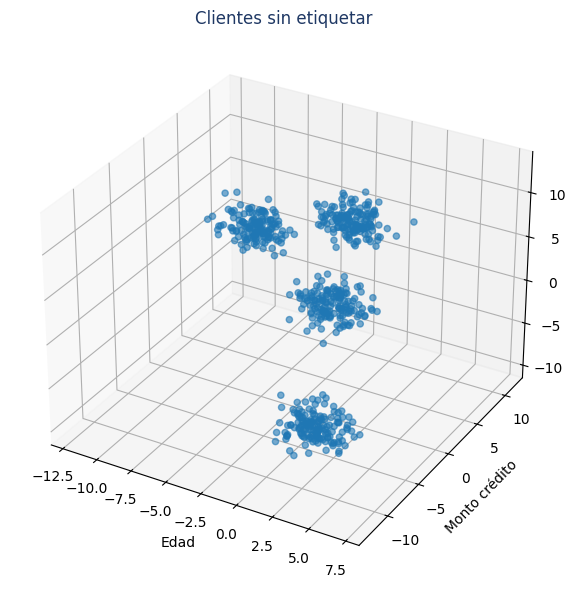

In [3]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(datos["Edad"], datos["Monto_credito"], datos["Duracion"], alpha=0.6)
ax.set_xlabel("Edad")
ax.set_ylabel("Monto crédito")
ax.set_zlabel("Duración")
ax.set_title("Clientes sin etiquetar", color=COLOR_TITULO)
plt.tight_layout()
plt.show()


Se aprecian nubes de puntos relativamente separadas: una primera señal visual de que **sí existe estructura** y de que agrupar tiene sentido. Más adelante lo confirmaremos con una prueba estadística.


<span style="color:#2E75B6;">**2.3 Estandarización (escalar los datos):**</span> Los algoritmos de agrupamiento miden **distancias**. Si una variable tiene números muy grandes (por ejemplo, el monto en pesos) dominará sobre las demás. Para evitarlo, **estandarizamos**: dejamos cada variable con media 0 y desviación 1, de modo que todas pesen lo mismo. Esto lo requiere k-means y lo hacemos con `StandardScaler`.


In [4]:
escalador = StandardScaler()
X_esc = escalador.fit_transform(datos[["Edad", "Monto_credito", "Duracion"]])

print("Media de cada variable (aprox 0):", np.round(X_esc.mean(axis=0), 3))
print("Desviación de cada variable (aprox 1):", np.round(X_esc.std(axis=0), 3))


Media de cada variable (aprox 0): [ 0. -0.  0.]
Desviación de cada variable (aprox 1): [1. 1. 1.]


Las medias quedaron en torno a 0 y las desviaciones en torno a 1. Los datos están listos y en igualdad de condiciones para medir distancias.


## **3. Tarea 1 — ¿Tiene sentido agrupar? (Tendencia a la agrupación)**

<span style="color:#2E75B6;">**3.1 Estadística de Hopkins:**</span> No siempre vale la pena agrupar. Si los datos están repartidos al azar, los "grupos" que encontremos serán artificiales. La **estadística de Hopkins** mide si los datos tienen una estructura **no aleatoria**:

- **Cercano a 1** → los datos están muy agrupados (vale la pena hacer clustering).
- **Cercano a 0,5** → los datos parecen aleatorios/uniformes (agrupar no aporta).

La idea: comparamos qué tan cerca están los puntos reales entre sí, frente a qué tan cerca estarían puntos repartidos al azar. La función siguiente implementa esa comparación.


In [5]:
def estadistica_hopkins(datos_esc, semilla=42):
    rng = np.random.RandomState(semilla)
    n, d = datos_esc.shape
    m = int(0.1 * n)
    vecinos = NearestNeighbors(n_neighbors=2).fit(datos_esc)
    indices = rng.choice(n, m, replace=False)
    w = vecinos.kneighbors(datos_esc[indices], n_neighbors=2,
                           return_distance=True)[0][:, 1]
    sinteticos = rng.uniform(datos_esc.min(axis=0),
                             datos_esc.max(axis=0), (m, d))
    u = vecinos.kneighbors(sinteticos, n_neighbors=1,
                           return_distance=True)[0][:, 0]
    return u.sum() / (u.sum() + w.sum())

H = estadistica_hopkins(X_esc)
print("Estadística de Hopkins:", round(H, 4))


Estadística de Hopkins: 0.9245


El valor obtenido es **H ≈ 0,92**, muy cercano a 1. Esto confirma que los datos **están fuertemente agrupados** y que aplicar clustering es una decisión correcta. (Como comprobación: sobre datos verdaderamente aleatorios esta misma función entrega un valor cercano a 0,5).


## **4. Tarea 2 — ¿En cuántos grupos? (Método de Elbow)**

<span style="color:#2E75B6;">**4.1 Método del Codo:**</span> El algoritmo k-means necesita que le digamos cuántos grupos buscar (el valor **K**). El **método de Elbow (codo)** nos ayuda a elegirlo. Calculamos el **WCSS** (suma de distancias de cada punto a su centro de grupo, también llamada *inercia*) para distintos valores de K.

A medida que aumentamos K, el WCSS siempre baja. Pero llega un punto donde añadir más grupos ya casi no mejora nada: ese "codo" en la curva marca el K adecuado.


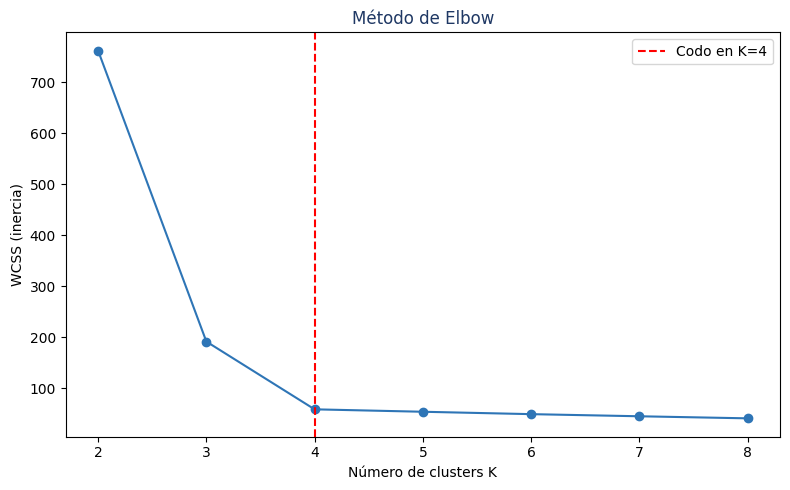

In [6]:
rango_k = range(2, 9)
inercias = []
for k in rango_k:
    km = KMeans(n_clusters=k, random_state=SEMILLA, n_init=10).fit(X_esc)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(rango_k), inercias, marker="o", color=COLOR_DESTACADO)
plt.axvline(x=4, color="red", linestyle="--", label="Codo en K=4")
plt.xlabel("Número de clusters K")
plt.ylabel("WCSS (inercia)")
plt.title("Método de Elbow", color=COLOR_TITULO)
plt.legend()
plt.tight_layout()
plt.show()


La curva cae muy fuerte hasta **K=4** y luego se aplana: ese es el "codo". El método de Elbow sugiere **4 grupos**, justo el número de segmentos que escondimos en los datos.


## **5. Validación Intrínseca (sin etiquetas verdaderas)**

<span style="color:#2E75B6;">**5.1 Métricas intrínsecas:**</span> Cuando **no** tenemos la respuesta correcta (el caso más común en la práctica), evaluamos la calidad mirando solo la forma de los grupos. Dos ideas guían estas métricas:

- **Cohesión:** los puntos de un mismo grupo deben estar juntos.
- **Separación:** los grupos distintos deben estar lejos entre sí.

Calcularemos dos métricas intrínsecas para cada K y las compararemos en una tabla.

- **Silhouette:** va de -1 a 1. Cercano a **+1** = grupos densos y bien separados.
- **Calinski-Harabaz (CH):** no tiene límite superior; **mientras más alto, mejor**.


In [7]:
filas = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=SEMILLA, n_init=10).fit(X_esc)
    etiquetas = km.labels_
    filas.append({
        "K": k,
        "WCSS": round(km.inertia_, 1),
        "Silhouette": round(silhouette_score(X_esc, etiquetas), 4),
        "Calinski_Harabaz": round(calinski_harabasz_score(X_esc, etiquetas), 1)
    })

tabla_intrinseca = pd.DataFrame(filas)
tabla_intrinseca


,K,WCSS,Silhouette,Calinski_Harabaz
0,2,762.3000,0.5909,814.1000
1,3,191.6000,0.7726,"2,505.4000"
2,4,58.7000,0.7742,"5,894.5000"
3,5,53.9000,0.6315,"4,816.3000"
4,6,49.2000,0.5164,"4,224.7000"
5,7,45.1000,0.4079,"3,848.8000"
6,8,41.0000,0.2623,"3,627.9000"


Ambas métricas coinciden: el **Silhouette** alcanza su máximo en **K=4 (≈0,77)** y el **Calinski-Harabaz** también es máximo en **K=4 (≈5894)**. Las dos apuntan al mismo número de grupos, lo que da confianza en la elección.


<span style="color:#2E75B6;">**5.2 Modelo final con K=4:**</span> Con K=4 decidido, entrenamos el modelo definitivo y asignamos a cada cliente su grupo.


In [8]:
modelo = KMeans(n_clusters=4, random_state=SEMILLA, n_init=10)
etiquetas_pred = modelo.fit_predict(X_esc)
datos["Cluster"] = etiquetas_pred

print("Cantidad de clientes por cluster:")
print(datos["Cluster"].value_counts().sort_index())


Cantidad de clientes por cluster:
Cluster
0    150
1    150
2    150
3    150
Name: count, dtype: int64


Los cuatro grupos quedaron **equilibrados** (150 clientes cada uno), lo que sugiere una partición sana, sin grupos diminutos ni uno que se trague a todos.


<span style="color:#2E75B6;">**5.3 Gráfico de Silhouette:**</span> El gráfico de Silhouette muestra, cliente por cliente, qué tan bien encaja en su grupo. Cada franja es un cluster; barras anchas y a la derecha (valores altos) indican buena pertenencia. La línea roja marca el promedio general.


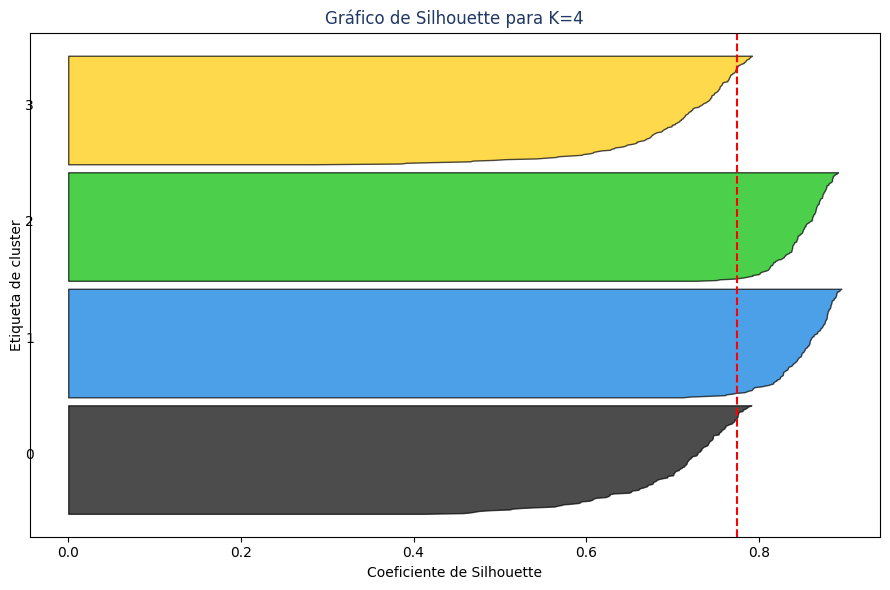

Silhouette promedio: 0.7742


In [9]:
sil_prom = silhouette_score(X_esc, etiquetas_pred)
valores_sil = silhouette_samples(X_esc, etiquetas_pred)

fig, ax = plt.subplots(figsize=(9, 6))
y_inf = 10
for i in range(4):
    vals = valores_sil[etiquetas_pred == i]
    vals.sort()
    tam = vals.shape[0]
    y_sup = y_inf + tam
    color = cm.nipy_spectral(float(i) / 4)
    ax.fill_betweenx(np.arange(y_inf, y_sup), 0, vals,
                     facecolor=color, edgecolor="black", alpha=0.7)
    ax.text(-0.05, y_inf + 0.5 * tam, str(i))
    y_inf = y_sup + 10

ax.axvline(x=sil_prom, color="red", linestyle="--")
ax.set_title("Gráfico de Silhouette para K=4", color=COLOR_TITULO)
ax.set_xlabel("Coeficiente de Silhouette")
ax.set_ylabel("Etiqueta de cluster")
ax.set_yticks([])
plt.tight_layout()
plt.show()

print("Silhouette promedio:", round(sil_prom, 4))


Las cuatro franjas son anchas y se extienden hacia la derecha, casi todas por encima del promedio (línea roja). No hay valores negativos relevantes, lo que indica que **casi ningún cliente quedó mal clasificado**.


<span style="color:#2E75B6;">**5.4 Estabilidad frente al azar:**</span> k-means parte de centros aleatorios, así que conviene comprobar si el resultado es **estable** al cambiar la semilla. Calculamos el Silhouette para varios K y varias semillas y lo mostramos como mapa de calor: colores parejos en una fila significan que ese K es robusto.


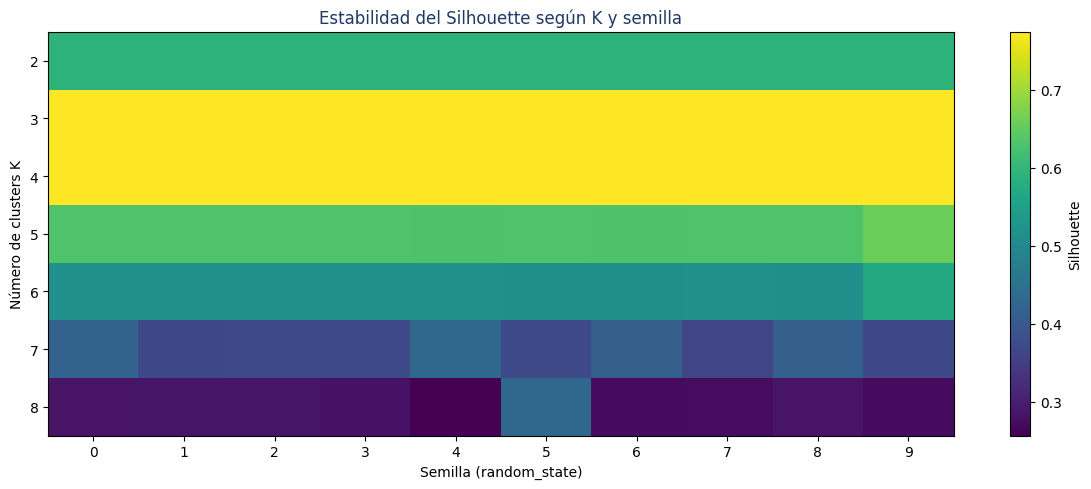

In [10]:
resultados = []
for k in range(2, 9):
    for s in range(0, 10):
        km = KMeans(n_clusters=k, random_state=s, n_init=10)
        lab = km.fit_predict(X_esc)
        resultados.append([k, s, silhouette_score(X_esc, lab)])

res = pd.DataFrame(resultados, columns=["K", "semilla", "silhouette"])
pivote = res.pivot_table(index="K", columns="semilla", values="silhouette")

plt.figure(figsize=(12, 5))
plt.imshow(pivote.values, aspect="auto", cmap="viridis")
plt.colorbar(label="Silhouette")
plt.yticks(range(len(pivote.index)), pivote.index)
plt.xticks(range(len(pivote.columns)), pivote.columns)
plt.xlabel("Semilla (random_state)")
plt.ylabel("Número de clusters K")
plt.title("Estabilidad del Silhouette según K y semilla", color=COLOR_TITULO)
plt.tight_layout()
plt.show()


La fila de **K=4** muestra los colores más altos y **parejos** a lo largo de todas las semillas: el resultado no depende del azar. Esto refuerza que 4 es una elección sólida.


## **6. Validación Extrínseca (con etiquetas verdaderas)**

<span style="color:#2E75B6;">**6.1 Métricas extrínsecas:**</span> Ahora usamos la "respuesta correcta" que habíamos escondido (`y_real`). La validación extrínseca compara los grupos del modelo contra los grupos reales. Es un enfoque **supervisado**, posible solo cuando un experto nos entrega las etiquetas verdaderas.

- **Índice de Rand Ajustado (ARI):** va de -1 a 1; mide qué proporción de asignaciones coincide, **ajustando el azar**. 1 = coincidencia perfecta.
- **Fowlkes-Mallows (FM):** se basa en la matriz de confusión (verdaderos positivos, falsos positivos y falsos negativos); es la media geométrica de precisión y sensibilidad. Más alto = mejor.


In [11]:
ari = adjusted_rand_score(y_real, etiquetas_pred)
fm = fowlkes_mallows_score(y_real, etiquetas_pred)

print("Índice de Rand Ajustado (ARI):", round(ari, 4))
print("Puntuación de Fowlkes-Mallows (FM):", round(fm, 4))


Índice de Rand Ajustado (ARI): 1.0
Puntuación de Fowlkes-Mallows (FM): 1.0


Ambos valores son **1,0**: el modelo recuperó **exactamente** los 4 segmentos reales. En problemas reales rara vez se llega a 1,0, pero aquí confirma que el procedimiento completo funcionó a la perfección sobre estos datos.


<span style="color:#2E75B6;">**6.2 Métricas extrínsecas para distintos K:**</span> Veamos cómo cambian ARI y FM al variar K. Esto demuestra que también las métricas extrínsecas señalan a K=4 como la mejor opción.


In [12]:
filas_ext = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=SEMILLA, n_init=10)
    lab = km.fit_predict(X_esc)
    filas_ext.append({
        "K": k,
        "ARI": round(adjusted_rand_score(y_real, lab), 4),
        "Fowlkes_Mallows": round(fowlkes_mallows_score(y_real, lab), 4)
    })

tabla_extrinseca = pd.DataFrame(filas_ext)
tabla_extrinseca


,K,ARI,Fowlkes_Mallows
0,2,0.4987,0.7059
1,3,0.7133,0.8156
2,4,1.0000,1.0000
3,5,0.9145,0.9364
4,6,0.8189,0.8664
5,7,0.7150,0.7909
6,8,0.5988,0.7059


Tanto ARI como FM son máximos (= 1,0) en **K=4** y empeoran al alejarse de ese valor. Las cuatro métricas (Silhouette, Calinski-Harabaz, ARI y Fowlkes-Mallows) **coinciden**: la mejor partición tiene 4 grupos.


## **7. Interpretación de Negocio: perfilando los clusters**

<span style="color:#2E75B6;">**7.1 Perfiles por cluster:**</span> Encontrar grupos no basta; hay que **entenderlos**. Calculamos el promedio de cada atributo por cluster para describir a qué tipo de cliente corresponde cada grupo. Este paso convierte el modelo en información útil para el área comercial.


In [13]:
perfiles = datos.groupby("Cluster")[["Edad", "Monto_credito", "Duracion"]].mean().round(2)
perfiles


,Edad,Monto_credito,Duracion
Cluster,,,
0,-8.7800,7.4500,2.0300
1,2.0200,-6.8100,-6.9000
2,4.1800,-9.3300,9.4100
3,-2.4200,9.0700,4.5000


Cada fila resume un **perfil de cliente** distinto (combinaciones diferentes de edad, monto y duración). Un banco como BancoChile podría, por ejemplo, ofrecer productos de largo plazo a un grupo y crédito de consumo rápido a otro, diseñando campañas específicas para cada segmento.


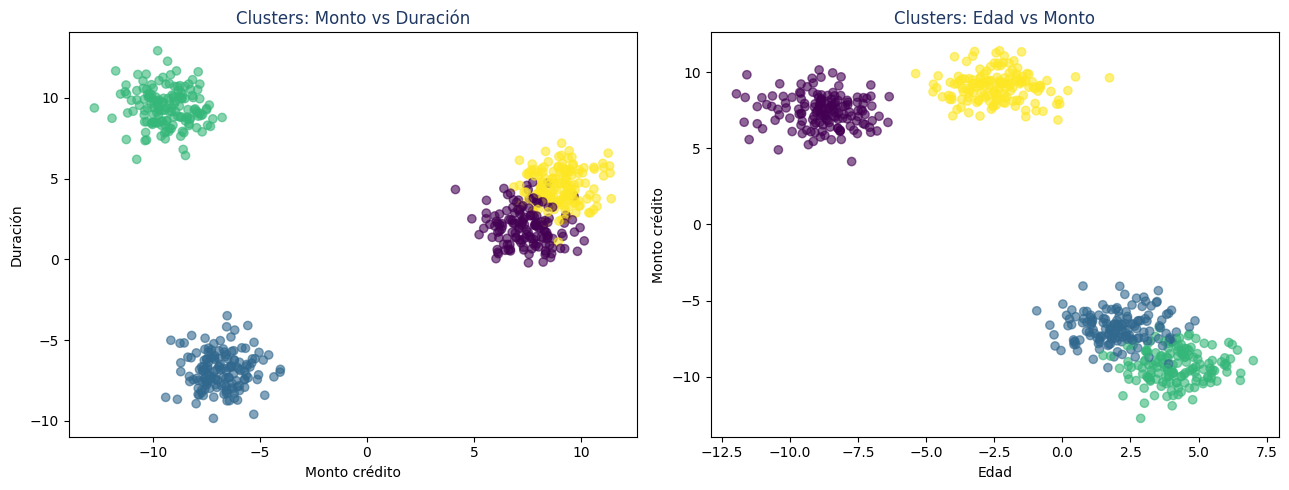

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(datos["Monto_credito"], datos["Duracion"],
                c=datos["Cluster"], cmap="viridis", alpha=0.6)
axes[0].set_xlabel("Monto crédito")
axes[0].set_ylabel("Duración")
axes[0].set_title("Clusters: Monto vs Duración", color=COLOR_TITULO)
axes[1].scatter(datos["Edad"], datos["Monto_credito"],
                c=datos["Cluster"], cmap="viridis", alpha=0.6)
axes[1].set_xlabel("Edad")
axes[1].set_ylabel("Monto crédito")
axes[1].set_title("Clusters: Edad vs Monto", color=COLOR_TITULO)
plt.tight_layout()
plt.show()


Los gráficos muestran los cuatro grupos **bien separados por color**, lo que confirma visualmente la buena calidad de la segmentación que las métricas ya habían cuantificado.


## **8. Resumen y Puntos Clave**

<span style="color:#2E75B6;">**8.1 Tabla resumen:**</span>

| Pregunta | Herramienta | Resultado |
|---|---|---|
| ¿Vale la pena agrupar? | Estadística de Hopkins | H ≈ 0,92 → sí |
| ¿Cuántos grupos? | Método de Elbow | K = 4 |
| Calidad sin etiquetas | Silhouette / Calinski-Harabaz | máximos en K = 4 |
| Calidad con etiquetas | ARI / Fowlkes-Mallows | = 1,0 en K = 4 |

**Ideas para recordar:**

- El agrupamiento es **no supervisado**: no hay una única respuesta correcta, por eso se evalúa de varias formas complementarias.
- Antes de agrupar, verifica que **exista estructura** (Hopkins). Antes de confiar en un K, **convérgelo** con Elbow y métricas de calidad.
- Si **no tienes etiquetas** → métricas **intrínsecas** (Silhouette, Calinski-Harabaz). Si **tienes etiquetas** → métricas **extrínsecas** (ARI, Fowlkes-Mallows).
- Comprueba la **estabilidad** frente al azar (varias semillas) y siempre cierra con la **interpretación de negocio**.

**Riesgos y cuidados:**

- Métricas como Silhouette favorecen grupos esféricos; con formas alargadas o densidades distintas pueden engañar.
- Olvidar **estandarizar** distorsiona las distancias y arruina el agrupamiento.
- Un buen número en una métrica no garantiza que los grupos tengan **sentido para el negocio**: la interpretación humana es insustituible.

---

## **Referencias (APA 7)**

- Han, J., Pei, J., & Tong, H. (2022). *Data mining: Concepts and techniques* (4th ed.). Morgan Kaufmann.
- Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., & Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

---

*Nota: Este notebook fue desarrollado por Benjamin Herrera como material de estudio para la asignatura BIY7121 - Minería de Datos.*
